In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('eBayClean.csv')
data

,UniqueID,sold,biddable,startprice,condition,cellular,carrier,color,storage,productline,noDescription,charCountDescription,upperCaseDescription,startprice_99end
0,10001,0,not biddable,159.99,used,No cellular,NaN,Black,Less than 128 GB,iPad 2,contains description,45,1,99 ending
1,10002,1,biddable,0.99,used,Cellular,Verizon,Unknown,Less than 128 GB,iPad 2,contains description,100,2,99 ending
2,10003,1,not biddable,199.99,used,No cellular,NaN,White,Less than 128 GB,iPad 4,no description,0,0,99 ending
3,10004,0,not biddable,235.00,new,No cellular,NaN,Unknown,Less than 128 GB,iPad mini 2,no description,0,0,not a 99 ending
4,10005,0,not biddable,199.99,refurbished,Unknown,Unknown,Unknown,Unknown,Unknown,contains description,100,2,99 ending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1856,11857,1,not biddable,239.95,used,No cellular,NaN,Black,Less than 128 GB,iPad 4,contains description,97,5,not a 99 ending
1857,11858,0,not biddable,329.99,new,No cellular,NaN,Space Gray,Less than 128 GB,iPad Air 1/2,contains description,93,1,99 ending
1858,11859,0,not biddable,400.00,new,No cellular,NaN,Gold,Less than 128 GB,iPad mini3,no description,0,0,not a 99 ending
1859,11860,1,not biddable,89.00,refurbished,No cellular,NaN,Black,Less than 128 GB,iPad 1,contains description,92,2,not a 99 ending


In [3]:
train = data.sample(frac = 0.7, random_state=1031)
test = data.drop(labels = train.index)

train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 1107 to 1463
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UniqueID              1303 non-null   int64  
 1   sold                  1303 non-null   int64  
 2   biddable              1303 non-null   object 
 3   startprice            1303 non-null   float64
 4   condition             1303 non-null   object 
 5   cellular              1303 non-null   object 
 6   carrier               520 non-null    object 
 7   color                 1303 non-null   object 
 8   storage               1303 non-null   object 
 9   productline           1303 non-null   object 
 10  noDescription         1303 non-null   object 
 11  charCountDescription  1303 non-null   int64  
 12  upperCaseDescription  1303 non-null   int64  
 13  startprice_99end      1303 non-null   object 
dtypes: float64(1), int64(4), object(9)
memory usage: 152.7+ KB


In [4]:
train.head()

,UniqueID,sold,biddable,startprice,condition,cellular,carrier,color,storage,productline,noDescription,charCountDescription,upperCaseDescription,startprice_99end
1107,11108,0,not biddable,196.0,used,Unknown,Unknown,White,Less than 128 GB,iPad 3,contains description,93,4,not a 99 ending
1833,11834,0,not biddable,529.0,new,No cellular,NaN,White,Less than 128 GB,iPad Air 1/2,no description,0,0,not a 99 ending
1351,11352,0,not biddable,425.0,used,Cellular,AT&T,Black,Less than 128 GB,iPad 2,no description,0,0,not a 99 ending
1576,11577,0,not biddable,315.0,used,Unknown,Unknown,Unknown,Less than 128 GB,iPad 4,no description,0,0,not a 99 ending
1170,11171,0,not biddable,275.0,used,No cellular,NaN,Space Gray,Less than 128 GB,iPad mini 2,no description,0,0,not a 99 ending


In [5]:
train.describe(include= 'all')

,UniqueID,sold,biddable,startprice,condition,cellular,carrier,color,storage,productline,noDescription,charCountDescription,upperCaseDescription,startprice_99end
count,1303.000000,1303.000000,1303,1303.000000,1303,1303,520,1303,1303,1303,1303,1303.000000,1303.000000,1303
unique,NaN,NaN,2,NaN,4,3,4,5,3,10,2,NaN,NaN,2
top,NaN,NaN,not biddable,NaN,used,No cellular,Unknown,Unknown,Less than 128 GB,iPad Air 1/2,no description,NaN,NaN,not a 99 ending
freq,NaN,NaN,711,NaN,810,780,249,496,1116,244,750,NaN,NaN,853
mean,10940.782809,0.469685,NaN,205.917567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.374520,2.674597,NaN
std,539.612222,0.499272,NaN,167.071431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.943174,8.920972,NaN
min,10001.000000,0.000000,NaN,0.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
25%,10470.500000,0.000000,NaN,79.990000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
50%,10942.000000,0.000000,NaN,175.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
75%,11406.500000,1.000000,NaN,300.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,2.000000,NaN


In [6]:
# Startprice
import matplotlib.pyplot as plt
import seaborn as sns

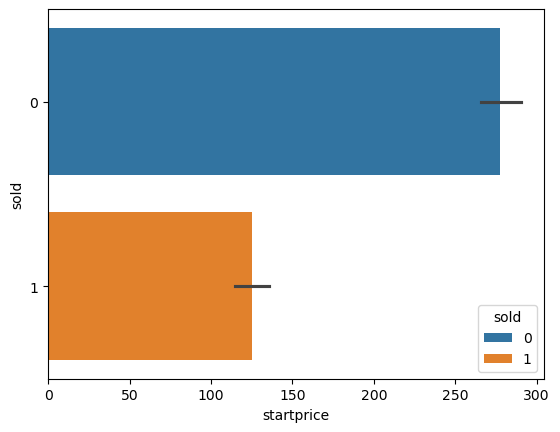

In [7]:
train_cat = train.copy()
train_cat['sold'] = train_cat['sold'].astype('category')
sns.barplot(data = train_cat,
            x = 'startprice',
            y = 'sold',
            hue = 'sold')
plt.show()

In [8]:
# Fit Model
from statsmodels.formula.api import logit

logreg = logit('sold~startprice', data = train)
model1 = logreg.fit()

Optimization terminated successfully.
         Current function value: 0.568922
         Iterations 6


In [10]:
model1.params

Intercept     1.314752
startprice   -0.007560
dtype: float64

In [11]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   sold   No. Observations:                 1303
Model:                          Logit   Df Residuals:                     1301
Method:                           MLE   Df Model:                            1
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.1770
Time:                        19:52:58   Log-Likelihood:                -741.30
converged:                       True   LL-Null:                       -900.77
Covariance Type:            nonrobust   LLR p-value:                 2.466e-71
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3148      0.109     12.094      0.000       1.102       1.528
startprice    -0.0076      0.001    -14.831      0.000      -0.009      -0.007
==============================================================================
"""

In [12]:
# Predict
import math
math.exp(model1.params.iloc[0] + model1.params.iloc[1]*200)/(1+ math.exp(model1.params.iloc[0] + model1.params.iloc[1]*200))

0.4508353468641195

In [13]:
startprice_200 = pd.DataFrame({'startprice': [200]})
model1.predict(startprice_200)

0    0.450835
dtype: float64

In [15]:
pd.DataFrame({'startprice': train.startprice,
              'predict-sold': model1.predict(),
              'sold': train.sold}).head(10)

,startprice,predict-sold,sold
1107,196.00,0.458333,0
1833,529.00,0.063887,0
1351,425.00,0.130295,0
1576,315.00,0.256027,0
1170,275.00,0.317710,0
8,0.99,0.787056,1
1852,279.00,0.311191,0
735,99.97,0.636211,1
717,159.95,0.526348,0
1693,15.00,0.768765,1


In [16]:
# Inference
print(model1.summary())


                           Logit Regression Results                           
Dep. Variable:                   sold   No. Observations:                 1303
Model:                          Logit   Df Residuals:                     1301
Method:                           MLE   Df Model:                            1
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.1770
Time:                        20:03:16   Log-Likelihood:                -741.30
converged:                       True   LL-Null:                       -900.77
Covariance Type:            nonrobust   LLR p-value:                 2.466e-71
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3148      0.109     12.094      0.000       1.102       1.528
startprice    -0.0076      0.001    -14.831      0.000      -0.009      -0.007


In [17]:
100*(math.exp(model1.params.iloc[1])-1)


-0.7531733458755463

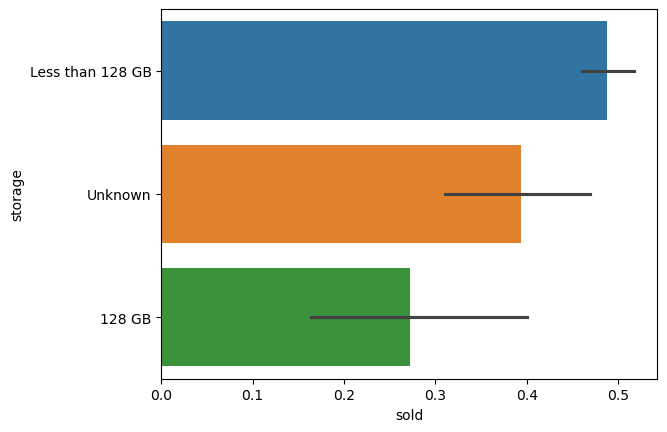

In [19]:
# Model 2: storage
sns.barplot(data= train,
            y = 'storage',
            x = 'sold',
            hue = 'storage')
plt.show()

In [21]:
# 1. Fit model
logreg = logit('sold~storage', data = train)
model2 = logreg.fit()

Optimization terminated successfully.
         Current function value: 0.686093
         Iterations 5


In [22]:
model2.params

Intercept                     -0.980829
storage[T.Less than 128 GB]    0.934226
storage[T.Unknown]             0.550046
dtype: float64

In [23]:
# 2. Predict
storage_less_128GB = pd.DataFrame({'storage' : ['Less than 128 GB']})
model2.predict(storage_less_128GB)

0    0.488351
dtype: float64

In [24]:
# 3.Inference
print(model2.summary())
print(model2.params.iloc[2])
print(math.exp(model2.params.iloc[2]))
print((math.exp(model2.params.iloc[2])-1)*100)

                           Logit Regression Results                           
Dep. Variable:                   sold   No. Observations:                 1303
Model:                          Logit   Df Residuals:                     1300
Method:                           MLE   Df Model:                            2
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                0.007543
Time:                        20:14:13   Log-Likelihood:                -893.98
converged:                       True   LL-Null:                       -900.77
Covariance Type:            nonrobust   LLR p-value:                  0.001120
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.9808      0.303     -3.240      0.001      -1.574      -0.387
storage[T.Less than 128 GB]     0.9342      0.309      3.027      0.002       0.

In [25]:
# Model 3: All Predictors
logreg = logit(formula='sold ~ biddable + startprice + condition + cellular + \
color + storage + productline + noDescription + upperCaseDescription + startprice_99end', data = train,)
model3 = logreg.fit()

Optimization terminated successfully.
         Current function value: 0.454808
         Iterations 7


In [26]:
# 1. Inference
print(model3.summary())
# chi_square_diff = model3.llf - model3.llnull

                           Logit Regression Results                           
Dep. Variable:                   sold   No. Observations:                 1303
Model:                          Logit   Df Residuals:                     1277
Method:                           MLE   Df Model:                           25
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.3421
Time:                        20:17:30   Log-Likelihood:                -592.61
converged:                       True   LL-Null:                       -900.77
Covariance Type:            nonrobust   LLR p-value:                4.666e-114
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               2.2508      0.672      3.349      0.001       0.934       3.568
biddable[T.not biddable]               -1.7329      0.15

In [27]:
# 2. Prediction
pd.DataFrame({'model1':[model1.aic, model1.prsquared],
              'model2':[model2.aic,model2.prsquared],
              'model3':[model3.aic,model3.prsquared],
              'metric': ['AIC','McFadden R2']}).set_index('metric')

,model1,model2,model3
metric,,,
AIC,1486.609809,1793.959605,1237.228657
McFadden R2,0.177036,0.007543,0.342106


In [28]:
pred = model3.predict()
results = pd.DataFrame({'sold': train.sold,
              'predicted_prob': pred,
              'pred_sold': (pred>0.5).astype('int32')})
results

,sold,predicted_prob,pred_sold
1107,0,0.125895,0
1833,0,0.081210,0
1351,0,0.027033,0
1576,0,0.044647,0
1170,0,0.288420,0
...,...,...,...
1509,0,0.601928,1
1020,0,0.041875,0
807,1,0.850285,1
1045,0,0.418667,0


In [29]:
np.mean(results.sold == results.pred_sold)

0.7966231772831927

In [30]:
# Predict out of Sample
pred = model3.predict(test)
results_test = pd.DataFrame({'sold': test.sold,
              'predicted_prob': pred,
              'pred_sold': (pred>0.5).astype('int32')})
results_test

,sold,predicted_prob,pred_sold
1,1,0.919324,1
5,1,0.885796,1
9,1,0.795386,1
11,0,0.400272,0
13,1,0.423842,0
...,...,...,...
1850,0,0.178627,0
1855,0,0.416494,0
1857,0,0.400198,0
1858,0,0.129402,0


In [31]:
np.mean(results_test.sold == results_test.pred_sold)


0.7741935483870968

In [34]:
y = data.sold
X = data.drop(['UniqueID', 'sold'], axis = 1)
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y,
                                                            random_state = 1031,
                                                            train_size = 0.7,
                                                            stratify=y)

In [35]:
# Transform Data
X_train_raw.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1302 entries, 1510 to 1075
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   biddable              1302 non-null   object 
 1   startprice            1302 non-null   float64
 2   condition             1302 non-null   object 
 3   cellular              1302 non-null   object 
 4   carrier               526 non-null    object 
 5   color                 1302 non-null   object 
 6   storage               1302 non-null   object 
 7   productline           1302 non-null   object 
 8   noDescription         1302 non-null   object 
 9   charCountDescription  1302 non-null   int64  
 10  upperCaseDescription  1302 non-null   int64  
 11  startprice_99end      1302 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 132.2+ KB


In [36]:
#categorical_features = ['biddable','condition','cellular', 'carrier', 'color','storage','productline','noDescription','startprice_99end']
categorical_features = X_train_raw.select_dtypes('object').columns

X_train = pd.get_dummies(X_train_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test = pd.get_dummies(X_test_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.head()

,startprice,charCountDescription,upperCaseDescription,biddable_not biddable,condition_new,condition_refurbished,condition_used,cellular_No cellular,cellular_Unknown,carrier_Sprint/T-Mobile,...,productline_iPad 2,productline_iPad 3,productline_iPad 4,productline_iPad Air 1/2,productline_iPad mini,productline_iPad mini 2,productline_iPad mini Retina,productline_iPad mini3,noDescription_no description,startprice_99end_not a 99 ending
1510,160.00,0,0,True,False,False,True,True,False,False,...,False,False,False,False,True,False,False,False,True,True
576,279.00,99,1,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1468,100.00,99,58,False,False,False,True,True,False,False,...,False,False,False,False,True,False,False,False,False,True
950,829.99,0,0,True,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
435,500.00,95,5,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,True


In [37]:
# Explore Data
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1302 entries, 1510 to 1075
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   startprice                        1302 non-null   float64
 1   charCountDescription              1302 non-null   int64  
 2   upperCaseDescription              1302 non-null   int64  
 3   biddable_not biddable             1302 non-null   bool   
 4   condition_new                     1302 non-null   bool   
 5   condition_refurbished             1302 non-null   bool   
 6   condition_used                    1302 non-null   bool   
 7   cellular_No cellular              1302 non-null   bool   
 8   cellular_Unknown                  1302 non-null   bool   
 9   carrier_Sprint/T-Mobile           1302 non-null   bool   
 10  carrier_Unknown                   1302 non-null   bool   
 11  carrier_Verizon                   1302 non-null   bool   
 12  color_Go

In [38]:
X_train.head()

,startprice,charCountDescription,upperCaseDescription,biddable_not biddable,condition_new,condition_refurbished,condition_used,cellular_No cellular,cellular_Unknown,carrier_Sprint/T-Mobile,...,productline_iPad 2,productline_iPad 3,productline_iPad 4,productline_iPad Air 1/2,productline_iPad mini,productline_iPad mini 2,productline_iPad mini Retina,productline_iPad mini3,noDescription_no description,startprice_99end_not a 99 ending
1510,160.00,0,0,True,False,False,True,True,False,False,...,False,False,False,False,True,False,False,False,True,True
576,279.00,99,1,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1468,100.00,99,58,False,False,False,True,True,False,False,...,False,False,False,False,True,False,False,False,False,True
950,829.99,0,0,True,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
435,500.00,95,5,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,True


In [42]:
# 1. Model 1: startprice
from sklearn.linear_model import LogisticRegression
from sklearn import set_config
set_config(display="diagram")


In [43]:
logit = LogisticRegression(max_iter=10000, random_state=1031)
logit.fit(X_train.loc[:,['startprice']], y_train)

LogisticRegression(max_iter=10000, random_state=1031)

In [ ]:
# Predict
